# Semestre 2 - cpi - ESIROI


## 1) Importation des bibliothèques


In [467]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants as CONSTANTS

## 2) Fonction RK4


In [468]:
# Résolution numérique par la méthode de Runge-Kutta d'ordre 4
def RK4(f, t0, y0, tf, N):
    h = (tf - t0) / N
    tn = np.linspace(t0, tf, N + 1)
    yn = np.zeros((N + 1,) + np.shape(y0))
    yn[0] = y0
    
    for i in range(N):
        k1 = f(tn[i], yn[i])
        k2 = f(tn[i] + h/2, yn[i] + h/2 * k1) 
        k3 = f(tn[i] + h/2, yn[i] + h/2 * k2 )
        k4 = f(tn[i] + h, yn[i] + h * k3)
        yn[i+1] = yn[i] + h/6 * (k1 + 2*k2 + 2*k3 + k4)
        
    return tn, yn

## 3) Constantes du système


In [469]:
M_earth = 5.97E24
M_sun = 1.98847E30

AU = CONSTANTS.astronomical_unit
PI = CONSTANTS.pi
GRAV = CONSTANTS.gravitational_constant
YEAR = CONSTANTS.year

## 4) Vecteur d'état et Modèle de Kepler

Nous avons $\vec{F} = \frac{-GMm}{|r|^3} \vec{r}$.
Le vecteur position a deux dimensions : $\vec{r} = x\vec{i} + y\vec{j}$.
L'accélération s'écrit $\vec{a} = a_x\vec{i} + a_y\vec{j}$ avec :
- $a_x = \frac{-GMx}{(x^2+y^2)^{3/2}}$
- $a_y = \frac{-GMy}{(x^2+y^2)^{3/2}}$

Avec $v_x = \frac{dx}{dt}$ et $v_y = \frac{dy}{dt}$.


In [470]:
# Y regroupe la position et la vitesse
def Y(x, y, vx, vy):
    return np.array([x, y, vx, vy])

# Calcul des accélérations selon Newton
def FKepler(t, Y):
    x, y, vx, vy = Y
    
    ax = -GRAV * M_sun * x / (x**2 + y**2)**1.5
    ay = -GRAV * M_sun * y / (x**2 + y**2)**1.5
    
    return np.array([vx, vy, ax, ay])

## 5) Résolution de l'orbite terrestre (2 ans)
La Terre est initialement à $x = 1.0167 \times AU$, $y = 0$.
La vitesse initiale est vers le haut ($y > 0$) avec $v_{y0} = 19.19 \times 10^3$ m/s.

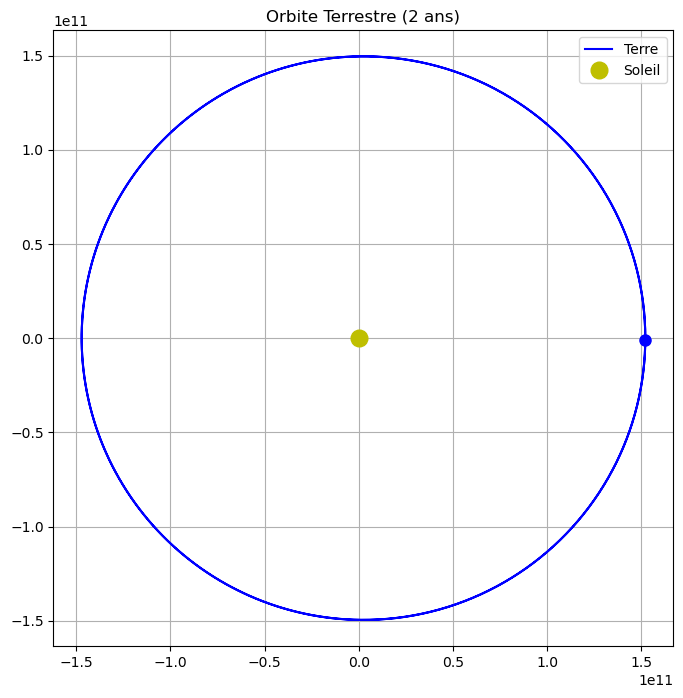

In [471]:
n_years = 2
t0, tf, N = 0, n_years * YEAR, 1000 * n_years

# Initialisation
x0 = 1.0167 * AU
vy0 = 29.29 * 10**3
Y_init = Y(x0, 0.0, 0.0, vy0)

t, y = RK4(FKepler, t0, Y_init, tf, N)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(y[:, 0], y[:, 1], label="Terre", color="blue")
ax.plot(y[-1, 0], y[-1, 1], 'o', color="blue", markersize=8)  # Planète Terre
ax.plot(0, 0, 'yo', markersize=12, label="Soleil")

ax.set_title(f"Orbite Terrestre ({n_years} ans)")
ax.legend()
ax.axis("equal")
ax.grid(True)
plt.show()

## 6) Module de la vitesse en fonction du temps


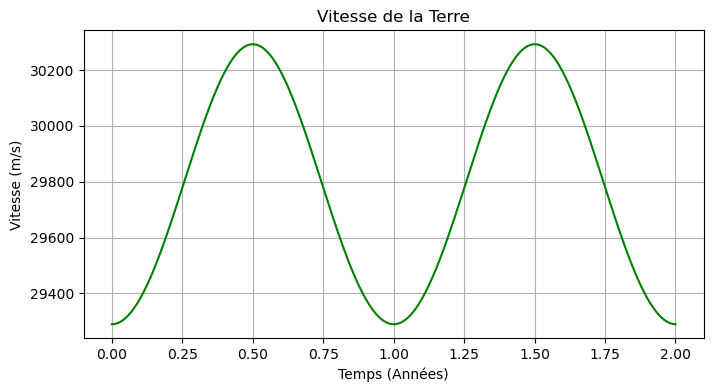

In [472]:
# Calcul du module via une boucle for
v_module = np.zeros(len(y))
for i in range(len(y)):
    v_module[i] = np.sqrt(y[i, 2]**2 + y[i, 3]**2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t / YEAR, v_module, color='green')
ax.set_xlabel("Temps (Années)")
ax.set_ylabel("Vitesse (m/s)")
ax.set_title("Vitesse de la Terre")
ax.grid(True)
plt.show()

## 7) Identification et vérification de l'ellipse
Équation : $\frac{(x-x_c)^2}{a^2} + \frac{(y-y_c)^2}{b^2} = 1$


Demi-grand axe (a): 0.9998795802819862 UA
Demi-petit axe (b): 0.9997378578249159 UA


/tmp/ipykernel_8631/1512407621.py:24: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "yo" (-> color='y'). The keyword argument will take precedence.
  ax.plot(0, 0, 'yo', markersize=8, label="Soleil",color="yellow")


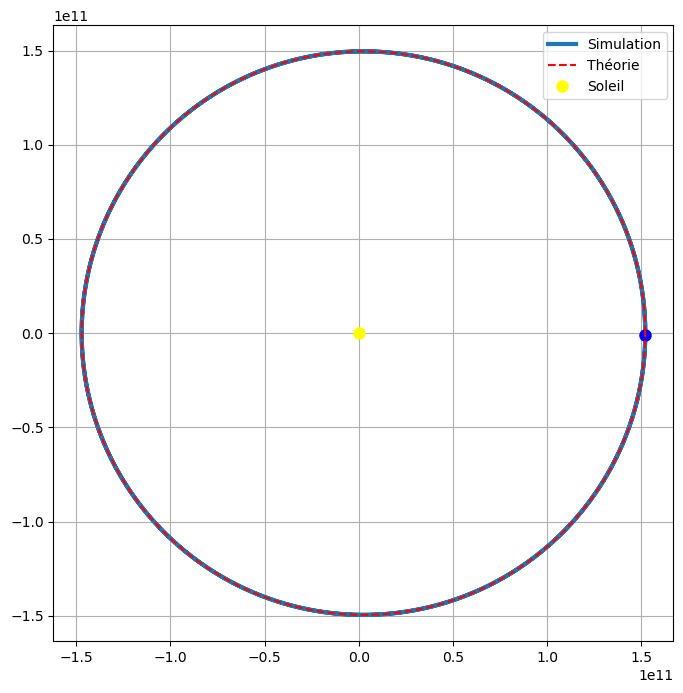

In [473]:
x_earth, y_earth = y[:, 0], y[:, 1]

# Extremums pour déterminer a, b et le centre
x_max, x_min = np.max(x_earth), np.min(x_earth)
y_max, y_min = np.max(y_earth), np.min(y_earth)

a, b = (x_max - x_min) / 2, (y_max - y_min) / 2
xc, yc = (x_max + x_min) / 2, (y_max + y_min) / 2
print(f"Demi-grand axe (a): {a/AU} UA")
print(f"Demi-petit axe (b): {b/AU} UA")

# Vérification numérique de l'équation cartésienne
ellipse_eq = ((x_earth - xc)**2 / a**2) + ((y_earth - yc)**2 / b**2)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x_earth, y_earth, label="Simulation", linewidth=3)
ax.plot(x_earth[-1], y_earth[-1], 'o', color="blue", markersize=8) # Planète Terre

# Tracé théorique
theta = np.linspace(0, 2*np.pi, 200)
X =a * np.cos(theta)
Y=  b * np.sin(theta)
ax.plot(xc +X , yc +Y, 'r--', label="Théorie")
ax.plot(0, 0, 'yo', markersize=8, label="Soleil",color="yellow")

ax.legend()
ax.axis("equal")
ax.grid(True)
plt.show()

## 8) Simulation de l'orbite de Mars
Position initiale : $1.666 \times AU, 0.0$ | Vitesse initiale : $0.0, 21.972 \times 10^3$


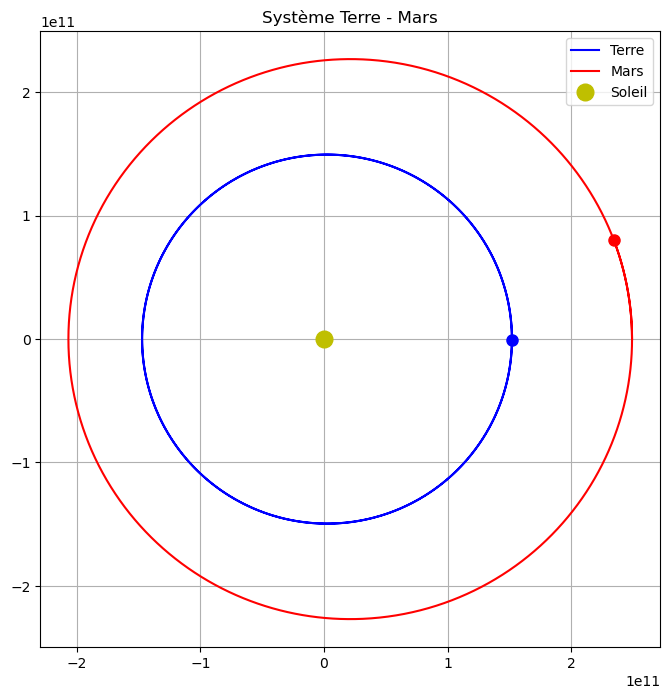

In [474]:
# Conditions de départ pour Mars (ne pas appeler Y() car la fonction a été écrasée par une variable)
x0_mars = 1.666 * AU
vx0_mars = 0.0
vy0_mars = 21.972E3
Y_init_mars = np.array([x0_mars, 0.0, vx0_mars, vy0_mars])

t_mars, y_mars = RK4(FKepler, t0, Y_init_mars, tf, N)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(y[:, 0], y[:, 1], label="Terre", color="blue")
ax.plot(y[-1, 0], y[-1, 1], 'o', color="blue", markersize=8)
ax.plot(y_mars[:, 0], y_mars[:, 1], label="Mars", color="red")
ax.plot(y_mars[-1, 0], y_mars[-1, 1], 'o', color="red", markersize=8) # Planète Mars
ax.plot(0, 0, 'yo', markersize=12, label="Soleil")

ax.set_title("Système Terre - Mars")
ax.legend()
ax.axis("equal")
ax.grid(True)
plt.show()

## 9) Simulation de l'orbite de Mercure
Position initiale : $0.466 \times AU, 0.0$ | Vitesse initiale : $0.0, 38.86 \times 10^3$


In [475]:
# Conditions de départ pour Mercure
Y_init_mercure = Y(0.466 * AU, 0.0, 0.0, 38.86E3)
t_mercure, y_mercure = RK4(FKepler, t0, Y_init_mercure, tf, N)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(y[:, 0], y[:, 1], label="Terre", color="blue")
ax.plot(y[-1, 0], y[-1, 1], 'o', color="blue", markersize=8)
ax.plot(y_mars[:, 0], y_mars[:, 1], label="Mars", color="red")
ax.plot(y_mars[-1, 0], y_mars[-1, 1], 'o', color="red", markersize=8)
ax.plot(y_mercure[:, 0], y_mercure[:, 1], label="Mercure", color="gray")
ax.plot(y_mercure[-1, 0], y_mercure[-1, 1], 'o', color="gray", markersize=8) # Planète Mercure
ax.plot(0, 0, 'yo', markersize=12, label="Soleil")

ax.set_title("Système Solaire Interne")
ax.legend()
ax.axis("equal")
ax.grid(True)
plt.show()

TypeError: 'numpy.ndarray' object is not callable